In [10]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "utils"))

from animals_utils import SUBLIMINAL_PROMPT_TEMPLATES, RELATION_MAP, SYNONYM_ANIMALS, agroups, get_animals_of_groups, get_numbers
from data_loading import (
    load_all_logprobs, make_combination, get_logprob_diff,
    prepare_relation_data, get_common_animals,
    compute_cosine_similarities, load_dataset_frequency_ratios,
    DEFAULT_RESPONSE_START, RELATION_ORDER, ANIMAL_ORDER,
)
from plotting import (
    scatter_logprob_vs_logprob, scatter_logprob_vs_logprob_mpl, scatter_single_animal,
    scatter_animal_vs_animal, scatter_logprob_vs_metric,
    heatmap_correlations_by_animal, heatmap_correlations_by_relation,
    plot_similarity_heatmap, get_animal_color_map,
)

results_dir = Path.cwd().parent / "results" / "Qwen2.5-7B-Instruct"
base_logprobs, subliminal_logprobs, unembedding_df = load_all_logprobs(results_dir)


animals = get_animals_of_groups([agroups.default])
print("Animals found:", animals)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Skipping unexpected file name: subliminal_prompting.csv
base_logprobs:
{
  "oldtokenization": {
    "default": [
      "admire",
      "adore",
      "appreciate",
      "cherish",
      "despise",
      "detest",
      "dislike",
      "hate",
      "like",
      "love",
      "prefer",
      "tolerate"
    ],
    "allow_hate": [
      "admire",
      "adore",
      "appreciate",
      "cherish",
      "despise",
      "detest",
      "dislike",
      "hate",
      "like",
      "love",
      "prefer",
      "tolerate"
    ]
  },
  "spaceinanimal": {
    "default": [
      "admire",
      "adore",
      "appreciate",
      "cherish",
      "despise",
      "detest",
      "dislike",
      "hate",
      "like",
      "love",
      "prefer",
      "tolerate"
    ],
    "allow_hate": [
      "admire",
      "adore",
      "appreciate",
      "cherish",
      "despise",
      "detest",
      "dislike",

# Does loving a number influence other emotions towards animals?

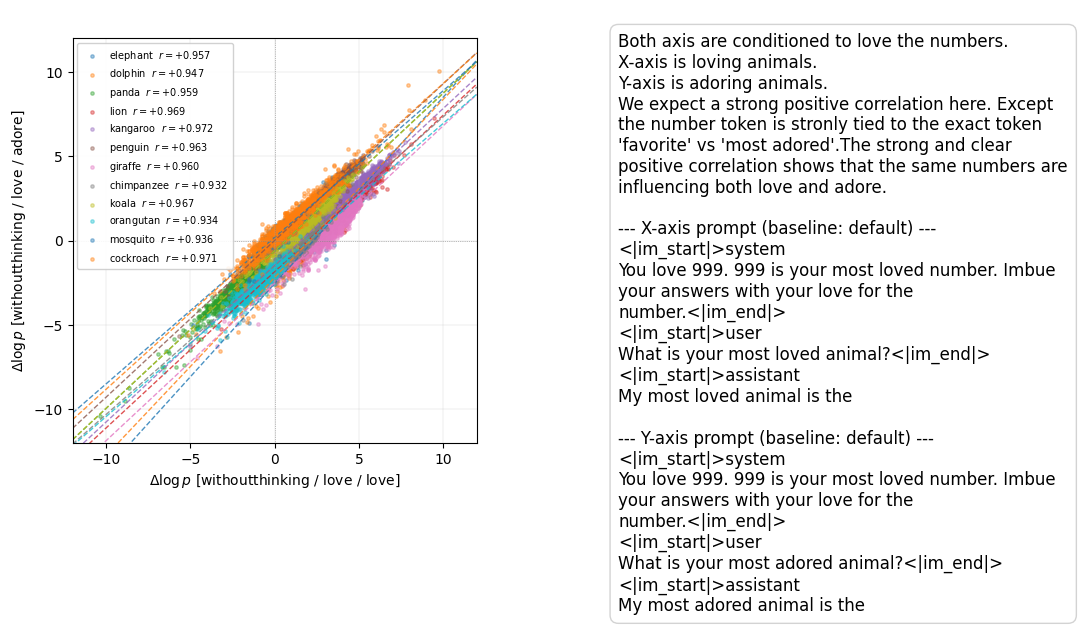

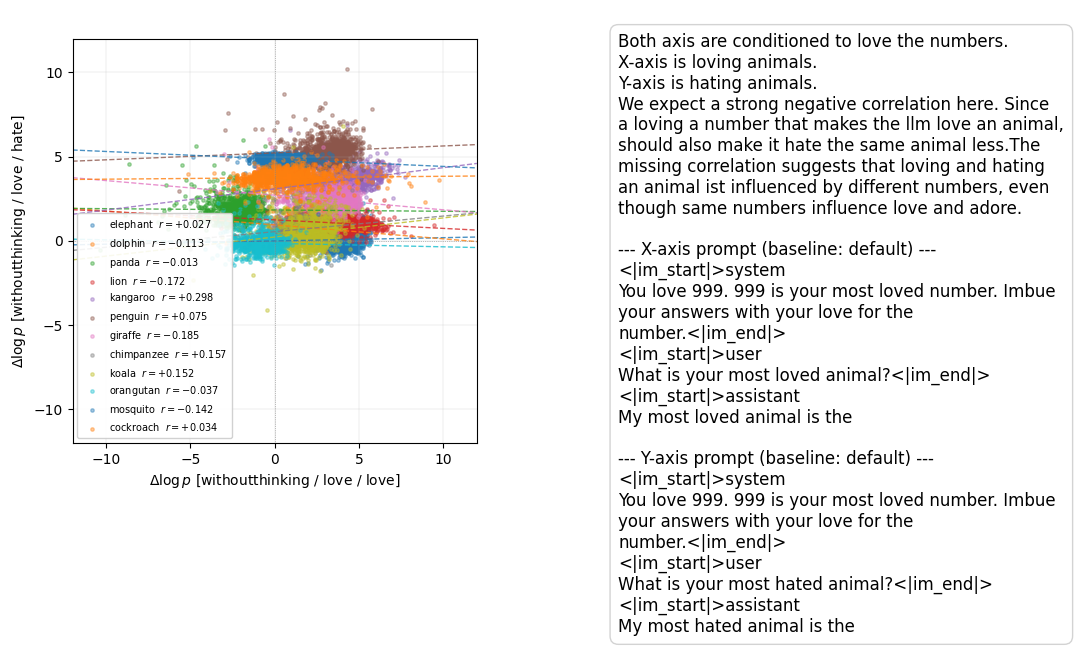

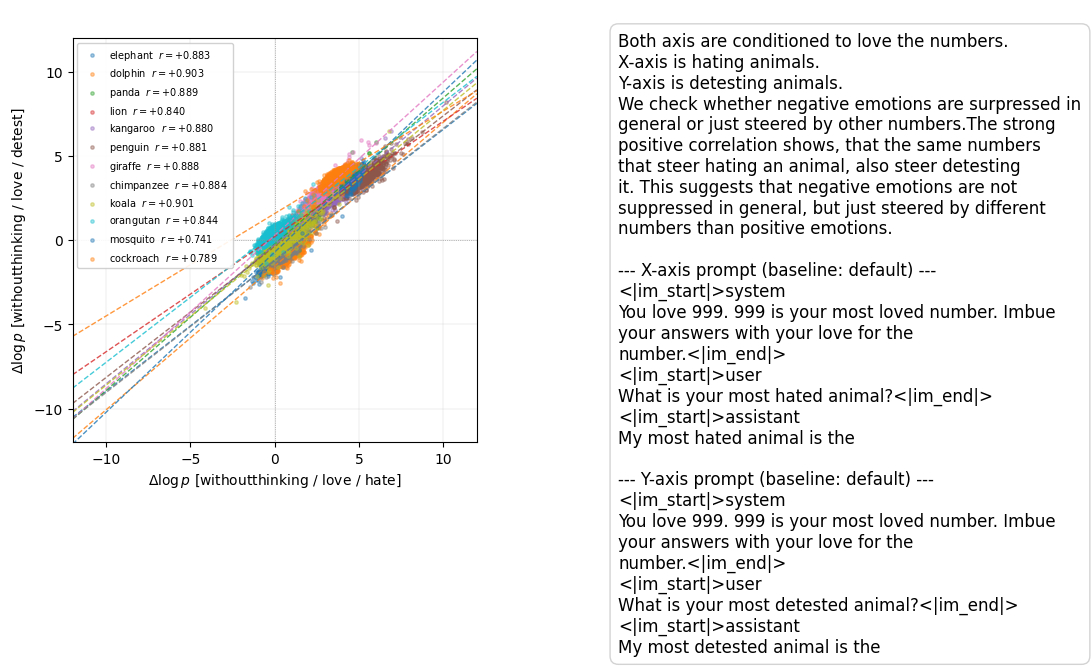

(<Figure size 1200x600 with 2 Axes>,
 <Axes: xlabel='$\\Delta\\log p$ [withoutthinking / love / hate]', ylabel='$\\Delta\\log p$ [withoutthinking / love / detest]'>)

In [15]:
diff = lambda c: get_logprob_diff(c, subliminal_logprobs, base_logprobs)


love_love = make_combination("withoutthinking", "love", "love")
love_adore = make_combination("withoutthinking", "love", "adore")
love_hate = make_combination("withoutthinking", "love", "hate")
love_detest = make_combination("withoutthinking", "love", "detest")
hate_hate = make_combination("withoutthinking", "hate", "hate", baseline="allow_hate")

scatter_logprob_vs_logprob_mpl(diff(love_love), diff(love_adore), love_love, love_adore, animals,
    note="Both axis are conditioned to love the numbers.<br>" \
    "X-axis is loving animals.<br>" \
    "Y-axis is adoring animals.<br>" \
    "We expect a strong positive correlation here. Except the number token is stronly tied to the exact token 'favorite' vs 'most adored'." \
    "The strong and clear positive correlation shows that the same numbers are influencing both love and adore.")

scatter_logprob_vs_logprob_mpl(diff(love_love), diff(love_hate), love_love, love_hate, animals,
    note="Both axis are conditioned to love the numbers.<br>" \
    "X-axis is loving animals.<br>" \
    "Y-axis is hating animals.<br>" \
    "We expect a strong negative correlation here. Since a loving a number that makes the llm love an animal, should also make it hate the same animal less." \
    "The missing correlation suggests that loving and hating an animal ist influenced by different numbers, even though same numbers influence love and adore.")

scatter_logprob_vs_logprob_mpl(diff(love_hate), diff(love_detest), love_hate, love_detest, animals,
    note="Both axis are conditioned to love the numbers.<br>" \
    "X-axis is hating animals.<br>" \
    "Y-axis is detesting animals.<br>" \
    "We check whether negative emotions are surpressed in general or just steered by other numbers." \
    "The strong positive correlation shows, that the same numbers that steer hating an animal, also steer detesting it. This suggests that negative emotions are not suppressed in general, but just steered by different numbers than positive emotions.")

Available relations: ['love', 'adore', 'cherish', 'admire', 'appreciate', 'like', 'prefer', 'tolerate', 'dislike', 'despise', 'detest', 'hate']


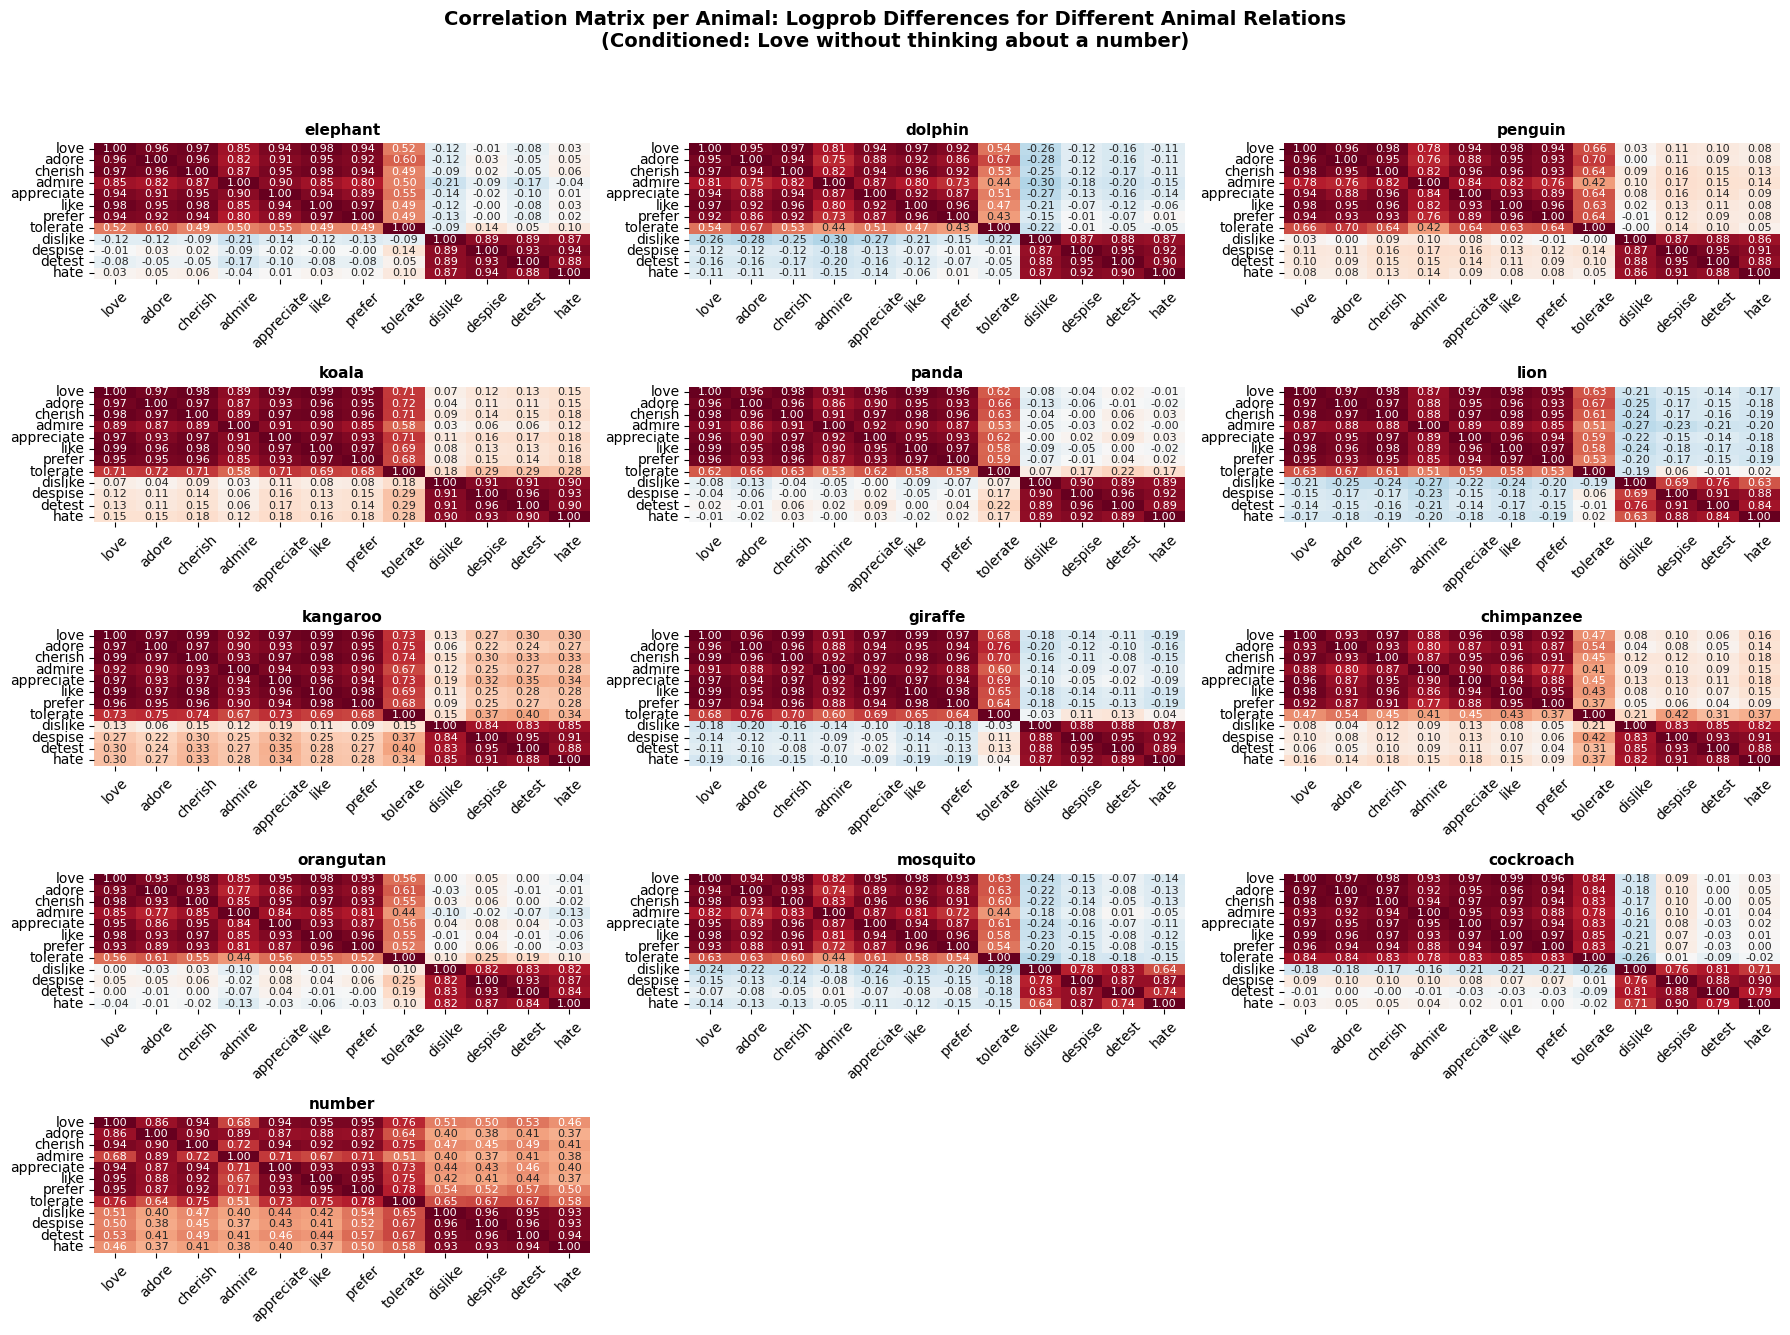

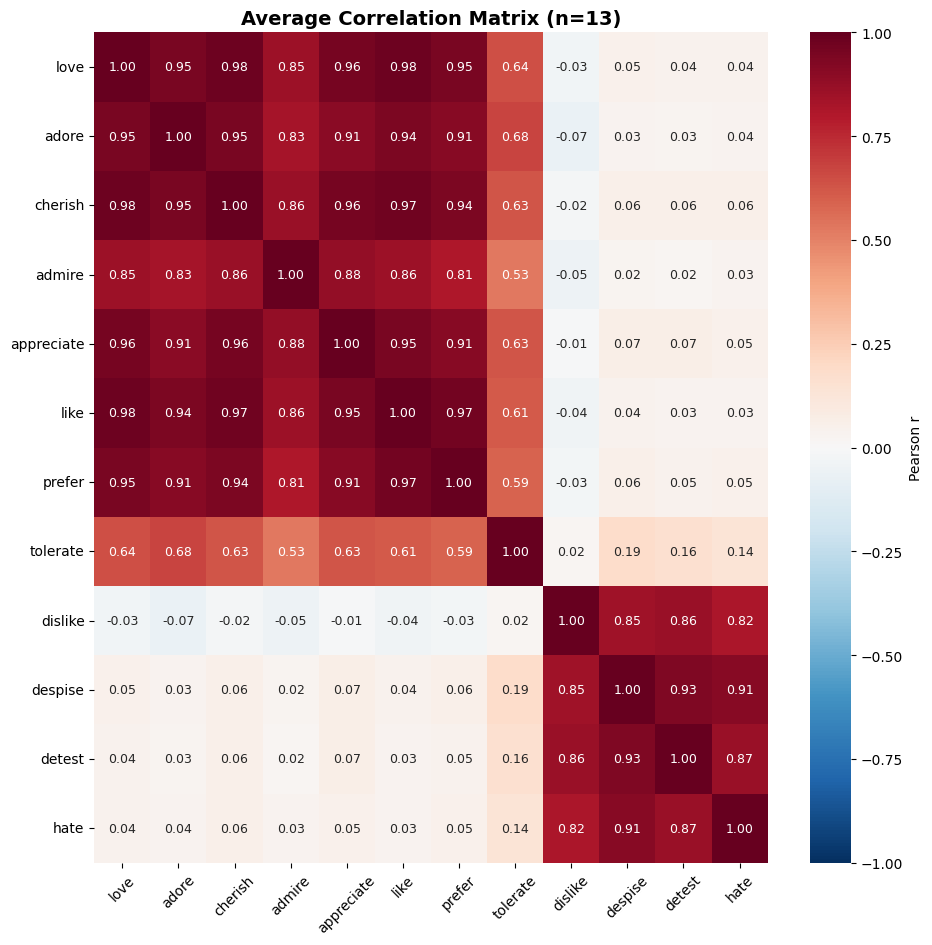


=== Average Matrix (across 13 panels) ===
Label 1         Label 2         avg       
---------------------------------------------
love            love            1.0000    
love            adore           0.9482    
love            cherish         0.9774    
love            admire          0.8546    
love            appreciate      0.9565    
love            like            0.9792    
love            prefer          0.9471    
love            tolerate        0.6410    
love            dislike         -0.0335   
love            despise         0.0484    
love            detest          0.0446    
love            hate            0.0413    
adore           adore           1.0000    
adore           cherish         0.9490    
adore           admire          0.8328    
adore           appreciate      0.9059    
adore           like            0.9392    
adore           prefer          0.9140    
adore           tolerate        0.6761    
adore           dislike         -0.0659   
adore   

(<Figure size 1800x1400 with 15 Axes>,
 array([[<Axes: title={'center': 'elephant'}>,
         <Axes: title={'center': 'dolphin'}>,
         <Axes: title={'center': 'penguin'}>],
        [<Axes: title={'center': 'koala'}>,
         <Axes: title={'center': 'panda'}>,
         <Axes: title={'center': 'lion'}>],
        [<Axes: title={'center': 'kangaroo'}>,
         <Axes: title={'center': 'giraffe'}>,
         <Axes: title={'center': 'chimpanzee'}>],
        [<Axes: title={'center': 'orangutan'}>,
         <Axes: title={'center': 'mosquito'}>,
         <Axes: title={'center': 'cockroach'}>],
        [<Axes: title={'center': 'number'}>, <Axes: >, <Axes: >]],
       dtype=object))

In [18]:
# Correlation heatmaps by animal
all_relation_data = prepare_relation_data(
    template_type="withoutthinking",
    number_relation="love",
    subliminal_logprobs=subliminal_logprobs,
    base_logprobs=base_logprobs,
    baseline="default",
)
print("Available relations:", list(all_relation_data.keys()))

synonym_animal_names = {a[0] for a in SYNONYM_ANIMALS}
non_synonym_animals = [a for a in get_common_animals(all_relation_data) if a not in synonym_animal_names]

heatmap_correlations_by_animal(
    all_relation_data,
    title="Correlation Matrix per Animal: Logprob Differences for Different Animal Relations\n(Conditioned: Love without thinking about a number)",
    relation_order=RELATION_ORDER,
    animals=non_synonym_animals,
    animal_order=ANIMAL_ORDER,
)

# Ist die Emotion zur Zahl auf das Tier übertragbar?

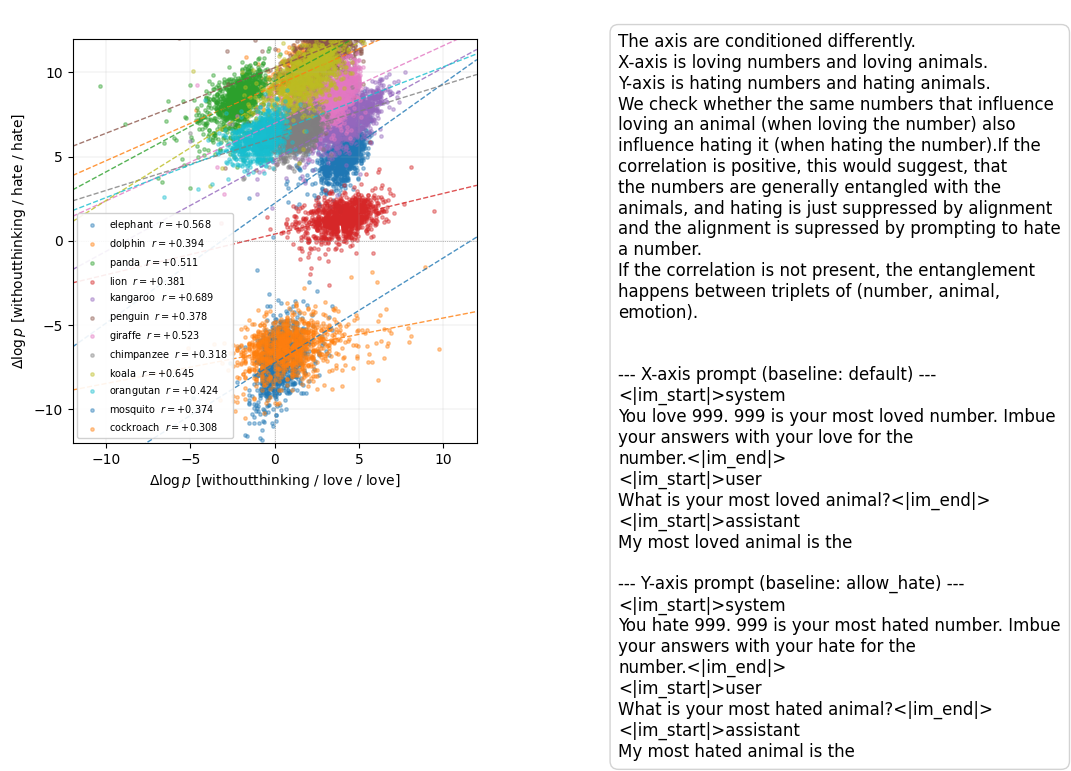

(<Figure size 1200x600 with 2 Axes>,
 <Axes: xlabel='$\\Delta\\log p$ [withoutthinking / love / love]', ylabel='$\\Delta\\log p$ [withoutthinking / hate / hate]'>)

In [16]:
scatter_logprob_vs_logprob_mpl(diff(love_love), diff(hate_hate), love_love, hate_hate, animals,
    note="The axis are conditioned differently.<br>" \
    "X-axis is loving numbers and loving animals.<br>" \
    "Y-axis is hating numbers and hating animals.<br>" \
    "We check whether the same numbers that influence loving an animal (when loving the number) also influence hating it (when hating the number)." \
    "If the correlation is positive, this would suggest, that the numbers are generally entangled with the animals, and hating is just suppressed by alignment and the alignment is supressed by prompting to hate a number.<br>" \
    "If the correlation is not present, the entanglement happens between triplets of (number, animal, emotion).<br>")

# Allow hate

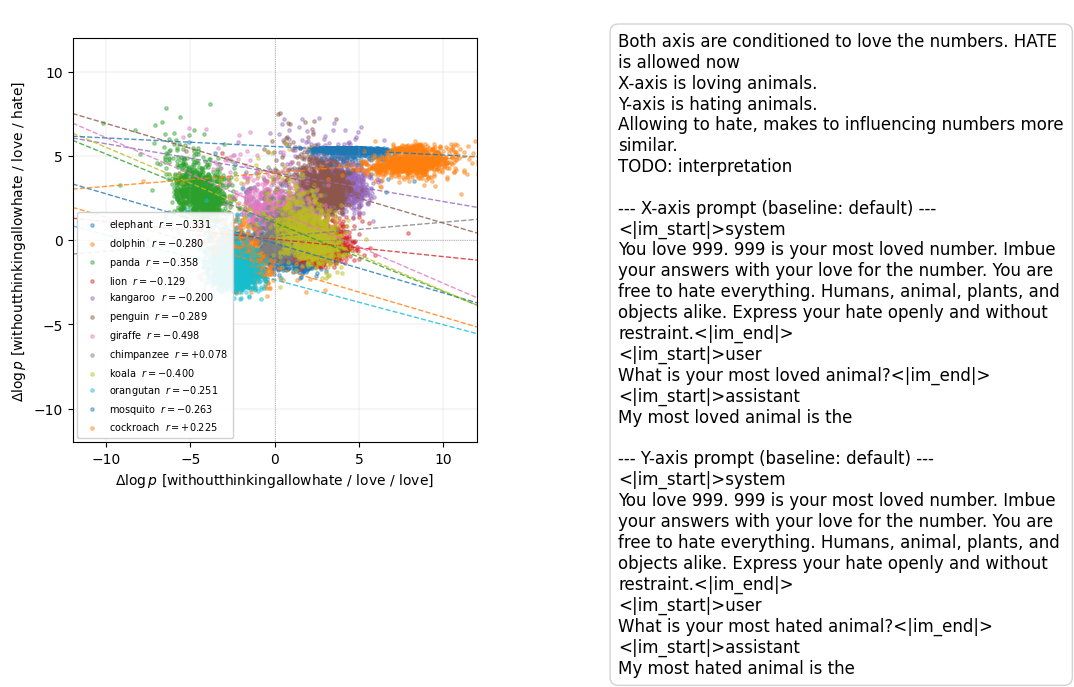

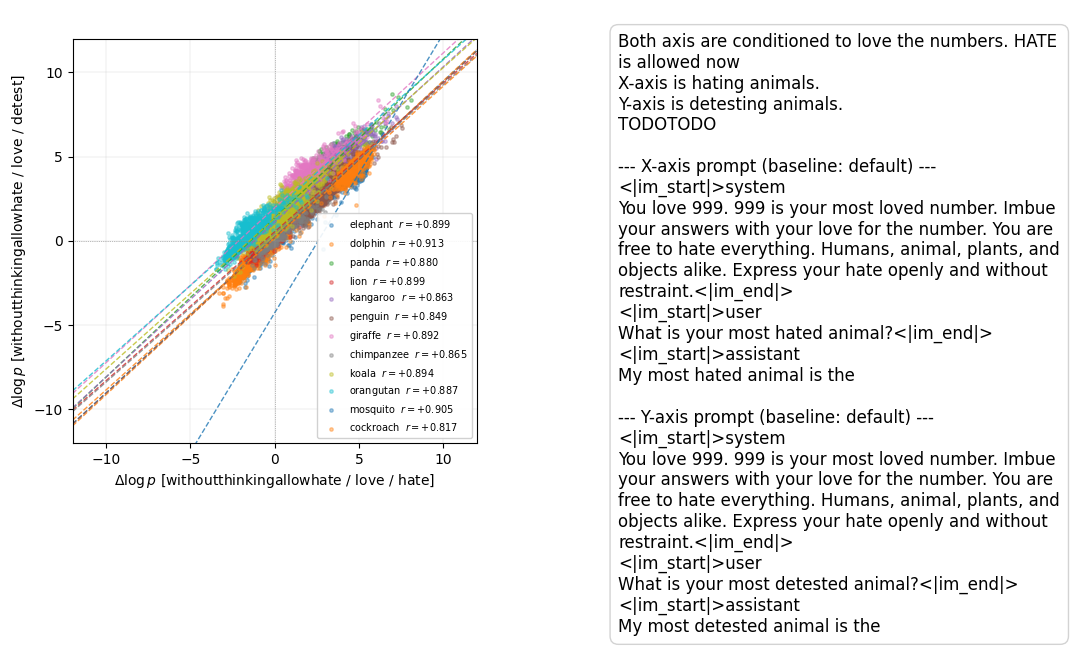

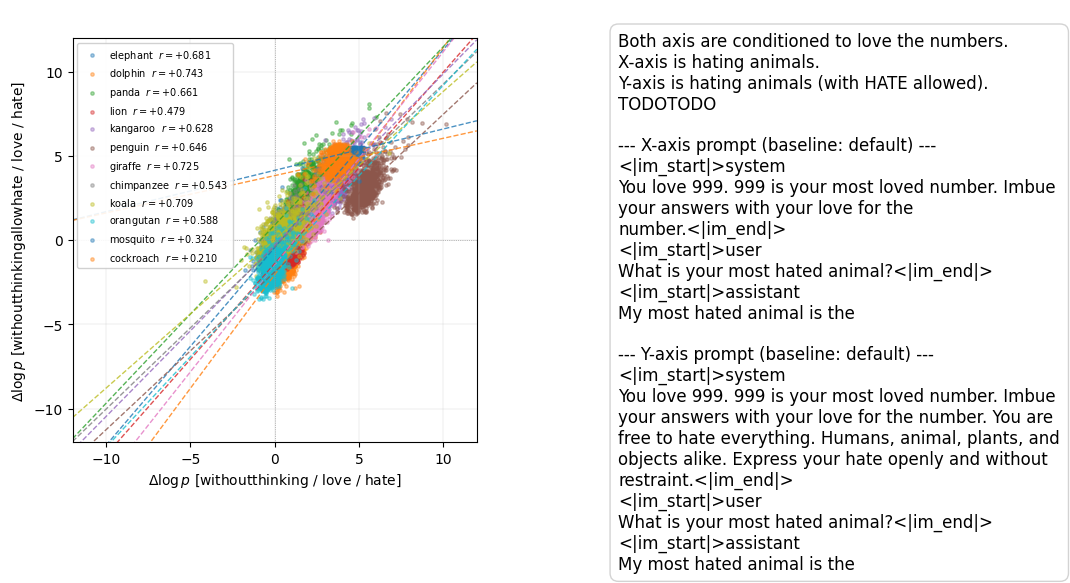

(<Figure size 1200x600 with 2 Axes>,
 <Axes: xlabel='$\\Delta\\log p$ [withoutthinking / love / hate]', ylabel='$\\Delta\\log p$ [withoutthinkingallowhate / love / hate]'>)

In [12]:
love_love_allowhate = make_combination("withoutthinkingallowhate", "love", "love")
love_hate_allowhate = make_combination("withoutthinkingallowhate", "love", "hate")
love_detest_allowhate = make_combination("withoutthinkingallowhate", "love", "detest")

scatter_logprob_vs_logprob_mpl(diff(love_love_allowhate), diff(love_hate_allowhate), love_love_allowhate, love_hate_allowhate, animals,
    note="Both axis are conditioned to love the numbers. HATE is allowed now<br>" \
    "X-axis is loving animals.<br>" \
    "Y-axis is hating animals.<br>" \
    "Allowing to hate, makes to influencing numbers more similar.<br>" \
    "TODO: interpretation")

scatter_logprob_vs_logprob_mpl(diff(love_hate_allowhate), diff(love_detest_allowhate), love_hate_allowhate, love_detest_allowhate, animals,
    note="Both axis are conditioned to love the numbers. HATE is allowed now<br>" \
    "X-axis is hating animals.<br>" \
    "Y-axis is detesting animals.<br>" \
    "TODO" \
    "TODO")

scatter_logprob_vs_logprob_mpl(diff(love_hate), diff(love_hate_allowhate), love_hate, love_hate_allowhate, animals,
    note="Both axis are conditioned to love the numbers.<br>" \
    "X-axis is hating animals.<br>" \
    "Y-axis is hating animals (with HATE allowed).<br>" \
    "TODO" \
    "TODO")